# Q1 residual-distribution figure -- prototype

**New, standalone notebook** -- built here instead of inside `results_figures_q1_rq2b.ipynb`
after a real file-collision there (another session's concurrent save silently erased an earlier
insert into that shared notebook). Self-contained: loads its own data rather than depending on
in-memory state from another notebook.

**Brainstormed alongside two other options** for "a Q1 headline result, made visual, via model
residuals": (a) a CanopyCover-vs-residual scatter (rejected -- not visually interesting), (b) a
plot-level full-resolution residual map (not attempted yet). This one -- residual distribution
comparison, EN vs. XGBoost -- was picked to prototype first.

**What it shows**: directly visualizes "XGBoost explains more of a plot's departure from the
shared curve than Elastic Net" via the shrinking/tightening spread of its leftover residuals,
tying straight to the R2 numbers already in the text (Set4: EN 0.358, XGBoost 0.395) -- a
different headline result from the EN-vs-XGBoost spatial map already built in
`results_figures_q1_rq2b.ipynb`'s Figure R2b-1 Panel C (that one is about spatial clustering;
this one is about raw prediction accuracy).

**Data**: `outputs/spatial_block_kfold/rq2_attribution_nested_set4_gated_all_vif/4survey/fold_{0-4}/predictions.csv`,
pooled across all 5 test folds, Set4 only, 4survey only -- same data `results_figures_q1_rq2b.ipynb`
already uses for its own Figure R2b-1. No new fitting.

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`. Prototype only --
not yet a finished, captioned figure.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks: walk upward
# until a folder containing both README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks.results_figures_style import COLOR_EN, COLOR_XGBOOST, apply_rcparams

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 5
Q1_SET4_DIR = project_root / "outputs" / "spatial_block_kfold" / "rq2_attribution_nested_set4_gated_all_vif" / "4survey"

In [3]:
frames = []
for fold in range(N_FOLDS):
    p = Q1_SET4_DIR / f"fold_{fold}" / "predictions.csv"
    frames.append(pd.read_csv(p))
pooled = pd.concat(frames, ignore_index=True)
pooled = pooled[pooled["split"] == "test"] if "split" in pooled.columns else pooled

pooled["en_residual"] = pooled["observed"] - pooled["elastic_net_predicted"]
pooled["xgb_residual"] = pooled["observed"] - pooled["xgboost_predicted"]

print(f"Pooled test rows: {len(pooled):,}")
print(f"EN residual:      SD={pooled['en_residual'].std():.3f}m, "
      f"IQR={pooled['en_residual'].quantile(0.75) - pooled['en_residual'].quantile(0.25):.3f}m")
print(f"XGBoost residual: SD={pooled['xgb_residual'].std():.3f}m, "
      f"IQR={pooled['xgb_residual'].quantile(0.75) - pooled['xgb_residual'].quantile(0.25):.3f}m")

Pooled test rows: 71,330
EN residual:      SD=4.447m, IQR=5.139m
XGBoost residual: SD=4.315m, IQR=4.888m


     method       sd      iqr
Elastic Net 4.446625 5.139118
    XGBoost 4.315395 4.887890


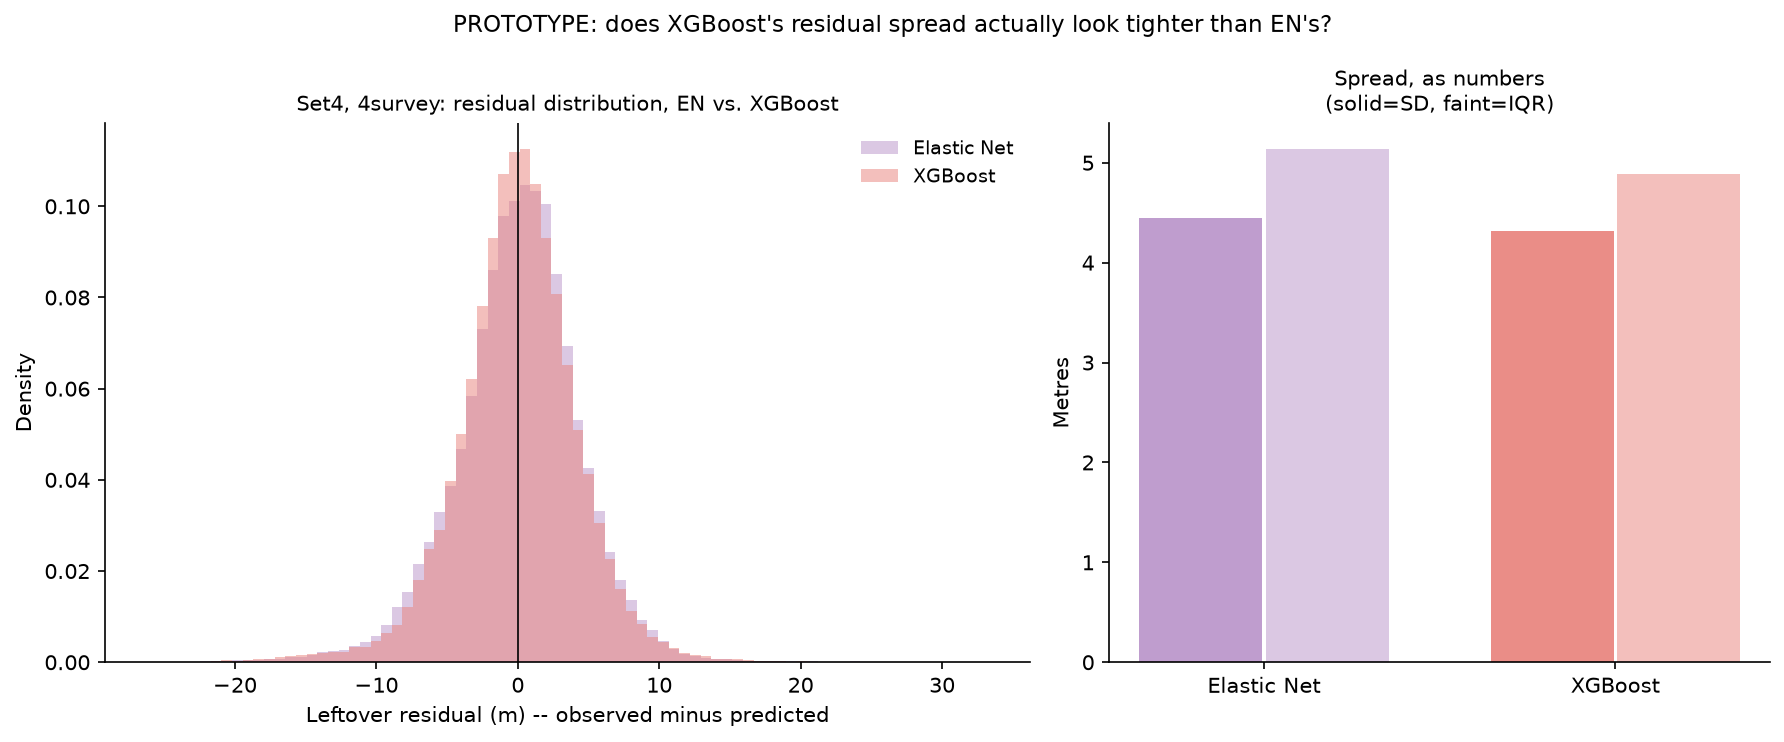

In [4]:
fig, (ax_hist, ax_summary) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.4, 1]})

# --- Left: overlaid histograms, shared bins so the spread comparison is fair (not each method
# auto-scaling its own bin width, which can visually exaggerate or hide the difference). ---
residual_range = (
    min(pooled["en_residual"].min(), pooled["xgb_residual"].min()),
    max(pooled["en_residual"].max(), pooled["xgb_residual"].max()),
)
shared_bins = np.linspace(*residual_range, 80)

ax_hist.hist(pooled["en_residual"], bins=shared_bins, color=COLOR_EN, alpha=0.5,
             density=True, label="Elastic Net")
ax_hist.hist(pooled["xgb_residual"], bins=shared_bins, color=COLOR_XGBOOST, alpha=0.5,
             density=True, label="XGBoost")
ax_hist.axvline(0, color="black", linewidth=0.8)
ax_hist.set_xlabel("Leftover residual (m) -- observed minus predicted")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Set4, 4survey: residual distribution, EN vs. XGBoost", fontsize=10)
ax_hist.legend(fontsize=9, frameon=False)

# --- Right: the same comparison as plain numbers -- SD and IQR, so the visual spread claim is
# backed by something a reader can check against the R2 table directly. ---
summary_rows = []
for label, column, color in [("Elastic Net", "en_residual", COLOR_EN), ("XGBoost", "xgb_residual", COLOR_XGBOOST)]:
    values = pooled[column]
    summary_rows.append({
        "method": label, "sd": values.std(),
        "iqr": values.quantile(0.75) - values.quantile(0.25),
        "color": color,
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df[["method", "sd", "iqr"]].to_string(index=False))

bar_x = np.arange(2)
ax_summary.bar(bar_x - 0.18, summary_df["sd"], width=0.35, color=summary_df["color"], alpha=0.9, label="SD")
ax_summary.bar(bar_x + 0.18, summary_df["iqr"], width=0.35, color=summary_df["color"], alpha=0.5, label="IQR")
ax_summary.set_xticks(bar_x)
ax_summary.set_xticklabels(summary_df["method"])
ax_summary.set_ylabel("Metres")
ax_summary.set_title("Spread, as numbers\n(solid=SD, faint=IQR)", fontsize=10)

fig.suptitle("PROTOTYPE: does XGBoost's residual spread actually look tighter than EN's?", fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "q1_residual_distribution_prototype.png", dpi=200)
plt.show()